In [1]:
from langchain_core.tools import tool
import httpx
from geopy.geocoders import Nominatim
import json

def get_coordinates(city_name: str) -> tuple[float, float]:
    """도시 이름을 받아 위도와 경도를 반환합니다."""
    geolocator = Nominatim(user_agent="weather_app_langgraph")
    location = geolocator.geocode(city_name)
    if location:
        return location.latitude, location.longitude
    raise ValueError(f"좌표를 찾을 수 없습니다: {city_name}")

@tool
def get_weather(city_name: str) -> str:
    """도시 이름을 받아 해당 도시의 현재 날씨 정보를 반환합니다."""
    print(f"날씨 조회: {city_name}")
    latitude, longitude = get_coordinates(city_name)
    url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current_weather=true"
    response = httpx.get(url)
    response.raise_for_status()
    return json.dumps(response.json())

tools = [get_weather]

In [2]:
get_coordinates("부산")

(35.1799528, 129.0752365)

In [3]:
tools[0].invoke({"city_name": "부산"})

날씨 조회: 부산


'{"latitude": 35.2, "longitude": 129.0625, "generationtime_ms": 0.03719329833984375, "utc_offset_seconds": 0, "timezone": "GMT", "timezone_abbreviation": "GMT", "elevation": 26.0, "current_weather_units": {"time": "iso8601", "interval": "seconds", "temperature": "\\u00b0C", "windspeed": "km/h", "winddirection": "\\u00b0", "is_day": "", "weathercode": "wmo code"}, "current_weather": {"time": "2025-09-19T10:30", "interval": 900, "temperature": 22.0, "windspeed": 6.8, "winddirection": 65, "is_day": 0, "weathercode": 3}}'

In [4]:
from langgraph.prebuilt import ToolNode # 에이전트와 도구 간의 인터페이스 역할을 하며, 언어 모델의 지시에 따라 실제 도구 실행을 담당하는 핵심적인 중간 다리
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash").bind_tools(tools)
tool_node = ToolNode([get_weather])

def call_model(state: MessagesState):
    return {"messages": [model.invoke(state["messages"])]}

graph_builder = StateGraph(MessagesState)
graph_builder.add_node("call_model", call_model)
graph_builder.add_node("tool_node", tool_node)

graph_builder.add_edge(START, "call_model")
graph_builder.add_conditional_edges(
    "call_model",
    lambda s: "tool_node" if s["messages"][-1].tool_calls else END,
    {"tool_node": "tool_node", END: END},
)
graph_builder.add_edge("tool_node", "call_model")

graph = graph_builder.compile()

E0000 00:00:1758278165.770566   45717 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


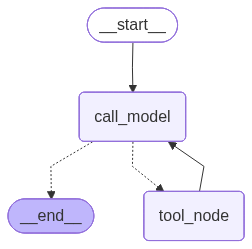

In [5]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [6]:
from langchain_core.messages import HumanMessage

query = "부산 날씨 어때?"
result = graph.invoke({"messages": [HumanMessage(content=query)]})

result

날씨 조회: 부산


{'messages': [HumanMessage(content='부산 날씨 어때?', additional_kwargs={}, response_metadata={}, id='28ac8c55-a2c8-4577-9cb0-84fb854cebf4'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city_name": "\\ubd80\\uc0b0"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--c963ac70-c5e3-457f-b3c7-d01acf7ac521-0', tool_calls=[{'name': 'get_weather', 'args': {'city_name': '부산'}, 'id': 'fbb7e092-5504-4d42-859f-9d4f32d36fc0', 'type': 'tool_call'}], usage_metadata={'input_tokens': 37, 'output_tokens': 8, 'total_tokens': 45, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='{"latitude": 35.2, "longitude": 129.0625, "generationtime_ms": 0.05066394805908203, "utc_offset_seconds": 0, "timezone": "GMT", "timezone_abbreviation": "GMT", "elevation": 26.0, "current_weather_units": {"time": "iso8601", "interval": "sec

In [7]:
result['messages'][-1].content

'부산의 현재 날씨는 22°C이고, 바람은 6.8km/h로 불고 있습니다.'

In [9]:
from langchain_core.messages import HumanMessage

query = "랭그래프에 대해 핵심만 간단히 설명해줘."
result = graph.invoke({"messages": [HumanMessage(content=query)]})

result

{'messages': [HumanMessage(content='랭그래프에 대해 핵심만 간단히 설명해줘.', additional_kwargs={}, response_metadata={}, id='94bb988c-411d-4940-b7af-326001f05848'),
  AIMessage(content='죄송합니다. 제가 랭그래프에 대해 알고 있는 내용이 없습니다.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--57df9ad6-58a1-4594-9dea-76ad759482fc-0', usage_metadata={'input_tokens': 47, 'output_tokens': 20, 'total_tokens': 67, 'input_token_details': {'cache_read': 0}})]}

In [10]:
print(result['messages'][-1].content)

죄송합니다. 제가 랭그래프에 대해 알고 있는 내용이 없습니다.
